In [1]:
# PREDICTING PRICE OF PRE-OWNED CARS
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm

In [2]:
# Setting dimensions for plot
sns.set(rc={'figure.figsize':(11.7,8.27)})

In [3]:
# Reading CSV file
cars_data=pd.read_csv('used_cars_dataset_v2.csv')

In [4]:
# Creating copy
cars=cars_data.copy()

In [5]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Brand         14993 non-null  object
 1   model         14993 non-null  object
 2   Year          14993 non-null  int64 
 3   Age           14993 non-null  int64 
 4   kmDriven      14905 non-null  object
 5   Transmission  14993 non-null  object
 6   Owner         14993 non-null  object
 7   FuelType      14993 non-null  object
 8   PostedDate    14993 non-null  object
 9   AdditionInfo  14993 non-null  object
 10  AskPrice      14993 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.3+ MB


In [6]:
cars['kmDriven']=cars['kmDriven'].astype(str).str.replace(' km','',regex=False)
cars['kmDriven']=cars['kmDriven'].str.replace(',','',regex=False)
cars['kmDriven']=pd.to_numeric(cars['kmDriven'], errors='coerce')

In [7]:
cars['AskPrice']=cars['AskPrice'].astype(str).str.replace('₹','',regex=False)
cars['AskPrice']=cars['AskPrice'].str.replace(',','',regex=False)
cars['AskPrice']=cars['AskPrice'].str.strip()
cars['AskPrice']=pd.to_numeric(cars['AskPrice'], errors='coerce')

In [8]:
cars=cars.rename(columns={'AskPrice':'price','kmDriven':'kilometer'})

In [9]:
# Summarizing data
cars.describe()
pd.set_option('display.float_format', lambda x: '%.3f' % x)
pd.set_option('display.precision',2)
cars.describe()

,Year,Age,kilometer,price
count,14993.000,14993.000,14905.000,14993.000
mean,2016.322,7.678,71078.348,997017.496
std,4.343,4.343,57458.286,1586639.685
min,1900.000,0.000,0.000,15000.000
25%,2014.000,5.000,44000.000,349000.000
50%,2017.000,7.000,65200.000,570000.000
75%,2019.000,10.000,86000.000,1025000.000
max,2024.000,124.000,980002.000,42500000.000


In [10]:
# To display maximum set of columns
pd.set_option('display.max_columns', 500)
cars.describe()

np.set_printoptions(suppress=True)

In [11]:
# Dropping unwanted columns
col=['PostedDate','AdditionInfo']
cars=cars.drop(columns=col)

In [12]:
# Removing duplicate records
cars.drop_duplicates(keep='first',inplace=True)

In [13]:
# Working range of data
cars = cars[
        (cars.Age >= 0)
      & (cars.Age <= 30)
      & (cars.price >= 10000)
      & (cars.price <= 5000000)
      & (cars.kilometer >= 100)
      & (cars.kilometer <= 500000)]

In [14]:
cars=cars.drop(columns=['Year'])

In [15]:
# Correlation
cars_select1=cars.select_dtypes(exclude=[object])
correlation=cars_select1.corr()
round(correlation,3)
cars_select1.corr().loc[:,'price'].abs().sort_values(ascending=False)[1:]

,price
Age,0.400
kilometer,0.164


In [ ]:
"""
We are going to build a Linear Regression model
on data obtained by omitting rows with any missing value
"""

In [16]:
# OMITTING MISSING VALUES
cars_omit=cars.dropna(axis=0)

In [17]:
# WRITING cars_omit AS .csv FILE
cars_omit.to_csv('omitted_data_cars_sampled.csv')

In [18]:
# Reading CSV file
cars_omit_data=pd.read_csv('omitted_data_cars_sampled.csv')

In [19]:
# Dropping the
cars_omit_data=cars_omit_data.drop('Unnamed: 0',axis=1)

In [ ]:
"""
Linear Regression
Model- price~kilometer+Age
"""

In [20]:
# Separating input and output features
x1 = cars_omit_data.filter(['kilometer','Age'],axis=1)
y1= cars_omit_data.filter(['price'],axis=1)

In [21]:
# Splitting data into test and train
X_train, X_test, y_train, y_test = train_test_split(x1, y1, test_size=0.3, random_state = 3)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(9263, 2) (3971, 2) (9263, 1) (3971, 1)


In [22]:
# Measure for multicollinearity
def calculateVIF(data):
    features = list(data.columns)
    num_features = len(features)

    model = LinearRegression()

    result = pd.DataFrame(index = ['VIF'], columns = features)
    result = result.fillna(0)

    for ite in range(num_features):
        x_features = features[:]
        y_featue = features[ite]
        x_features.remove(y_featue)
        model.fit(data[x_features], data[y_featue])
        result[y_featue] = 1/(1 - model.score(data[x_features], data[y_featue]))

    return result

In [ ]:
"""
Model evaluation
"""

In [23]:
def rmse(test_y,predicted_y):
    rmse_test=np.sqrt(mean_squared_error(test_y, predicted_y))
    #for base rmse
    base_pred = np.repeat(np.mean(test_y), len(test_y))
    rmse_base = np.sqrt(mean_squared_error((test_y), base_pred))
    values={'RMSE-test from model':rmse_test,'Base RMSE':rmse_base}
    return values

In [ ]:
"""
Linear regression model building starts here
"""

In [24]:
X_train2 = sm.add_constant(X_train)
model_lin1 = sm.OLS(y_train, X_train2)
results1=model_lin1.fit()
print(results1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     874.6
Date:                Thu, 13 Aug 2026   Prob (F-statistic):               0.00
Time:                        20:44:59   Log-Likelihood:            -1.3833e+05
No. Observations:                9263   AIC:                         2.767e+05
Df Residuals:                    9260   BIC:                         2.767e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.433e+06   1.85e+04     77.390      0.0

In [25]:
# Predicting model on test set
X_test=sm.add_constant(X_test)
cars_predictions_lin1_test = results1.predict(X_test)

In [26]:
vif_val=calculateVIF(X_train)
vif_val=vif_val.transpose()

/tmp/ipykernel_1409/2338710076.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result = result.fillna(0)


In [27]:
# Model evaluation on predicted and test
rmse(y_test,cars_predictions_lin1_test)

{'RMSE-test from model': np.float64(746287.2790477333),
 'Base RMSE': np.float64(815335.427202922)}

In [28]:
# For diagnostics, we need to predict the model on the train data
cars_predictions_lin1_train = results1.predict(X_train2)

In [29]:
"""
Diagnostics
"""

'\nDiagnostics\n'

In [30]:
residuals=y_train.iloc[:,0]-cars_predictions_lin1_train


Text(0.5, 1.0, 'Residual plot')

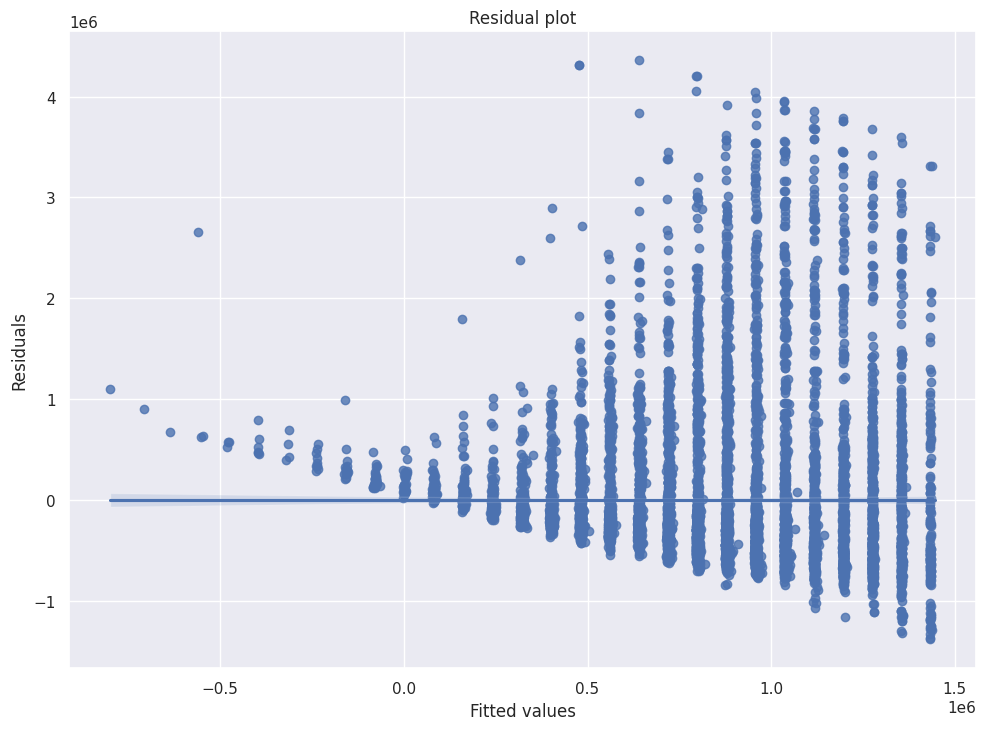

In [31]:
# Residual plot
sns.regplot(x=cars_predictions_lin1_train,y=residuals)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title('Residual plot')

Text(0.5, 1.0, 'Normal Q-Q Plot')

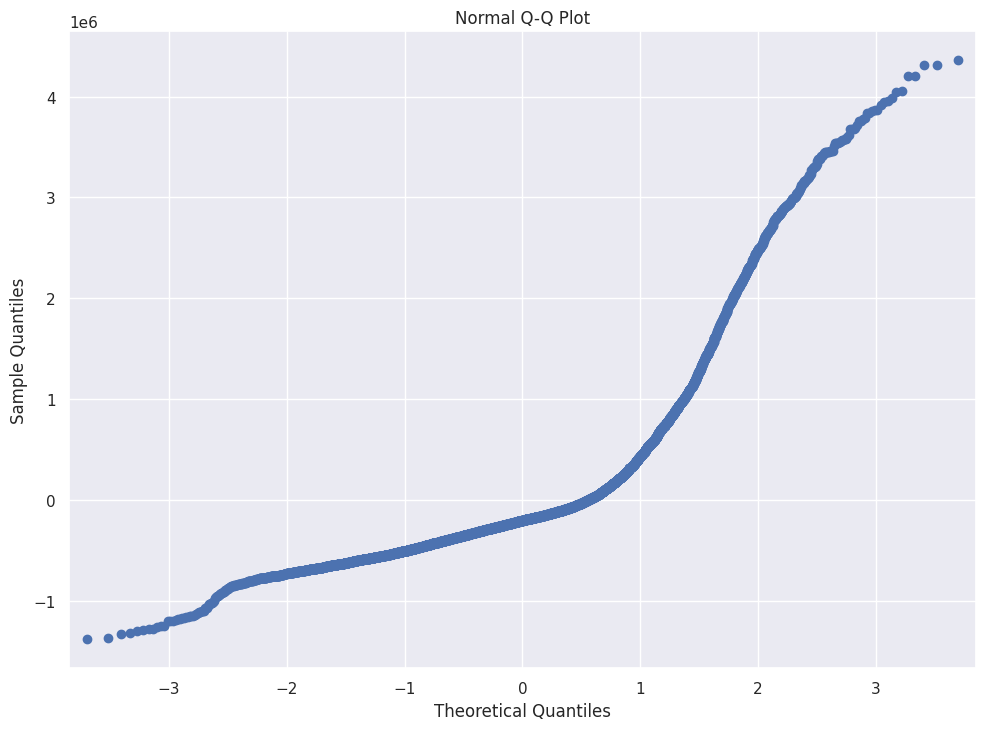

In [32]:
# QQ plot
sm.qqplot(residuals)
plt.title("Normal Q-Q Plot")

array([[<Axes: title={'center': '1. Before'}>,
        <Axes: title={'center': '2. After'}>]], dtype=object)

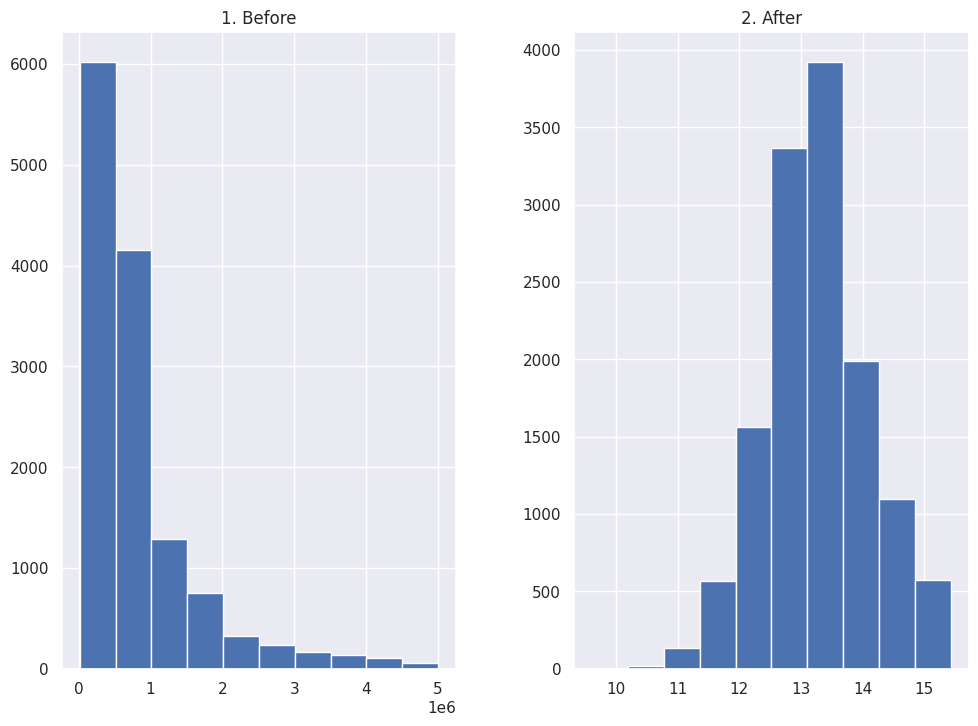

In [33]:
# Plotting the variable price
prices = pd.DataFrame({"1. Before":y1.iloc[:,0], "2. After":np.log(y1.iloc[:,0])})
prices.hist()

array([[<Axes: title={'center': '1. Before'}>,
        <Axes: title={'center': '2. After'}>]], dtype=object)

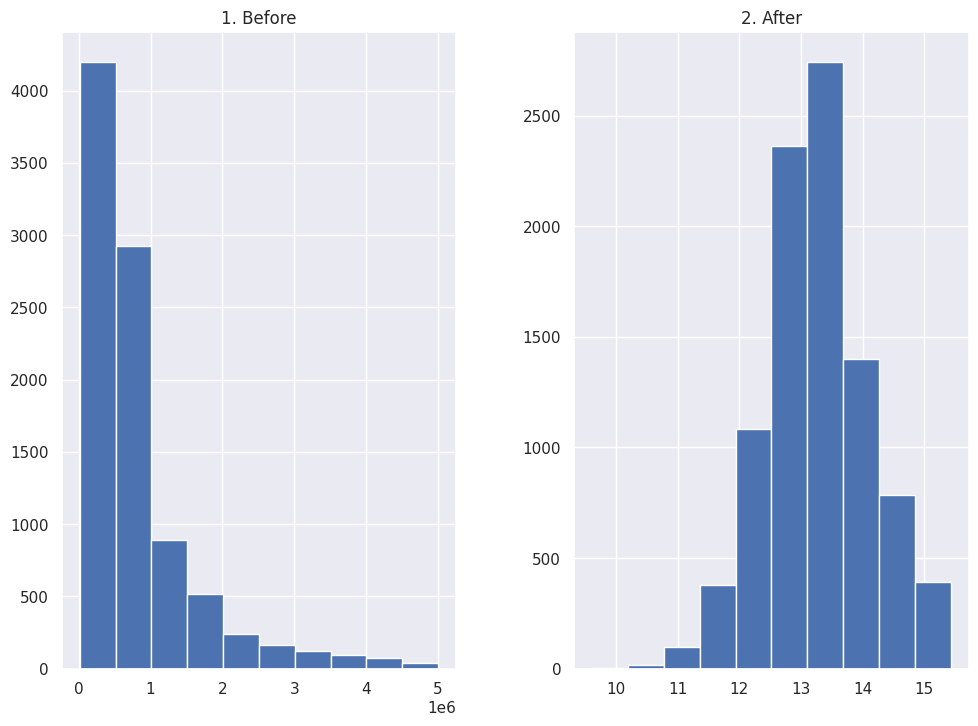

In [34]:
# Plotting the variable price
prices = pd.DataFrame({"1. Before":y_train.iloc[:,0], "2. After":np.log(y_train.iloc[:,0])})
prices.hist()

array([[<Axes: title={'center': '1. Before'}>,
        <Axes: title={'center': '2. After'}>]], dtype=object)

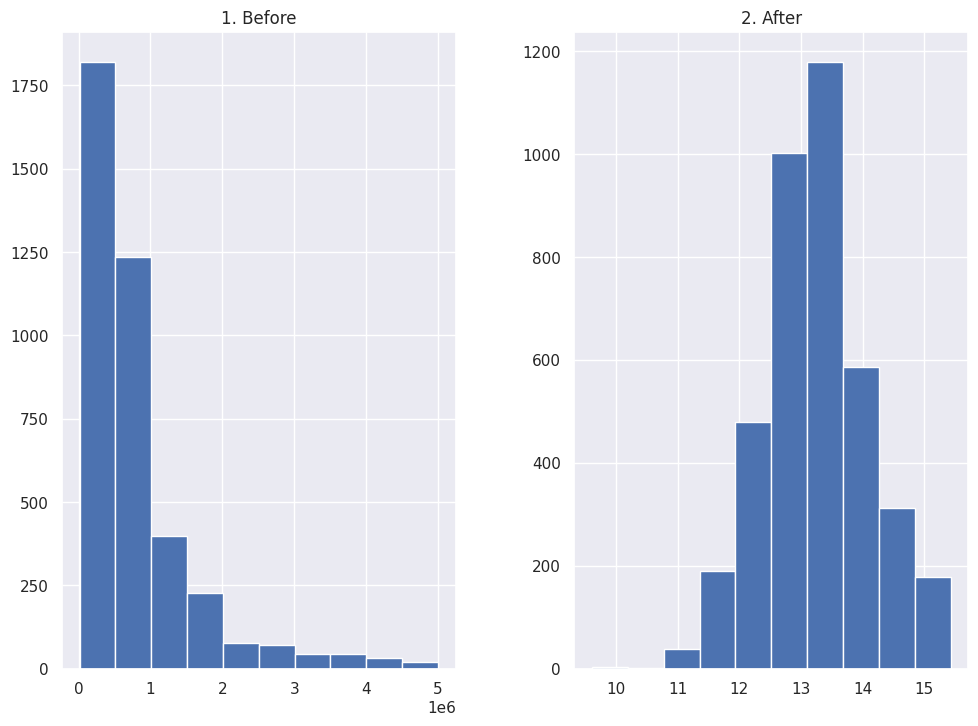

In [35]:
# Plotting the variable price
prices = pd.DataFrame({"1. Before":y_test.iloc[:,0], "2. After":np.log(y_test.iloc[:,0])})
prices.hist()

In [36]:
# Transforming prices to log
y2=np.log(y1)
y_train_log,y_test_log=train_test_split(y2, test_size=0.3, random_state = 3)

In [37]:
"""
Linear Regression
Model- log(price)~kilometer+Age
"""

'\nLinear Regression\nModel- log(price)~kilometer+Age\n'

In [38]:
X_train2 = sm.add_constant(X_train)
model_lin2 = sm.OLS(y_train_log, X_train2)
results2=model_lin2.fit()
print(results2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.350
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                     2489.
Date:                Thu, 13 Aug 2026   Prob (F-statistic):               0.00
Time:                        20:47:17   Log-Likelihood:                -9476.1
No. Observations:                9263   AIC:                         1.896e+04
Df Residuals:                    9260   BIC:                         1.898e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.1425      0.017    839.831      0.0

In [39]:
# Predicting model on test set
X_test=sm.add_constant(X_test)
cars_predictions_lin2_test = results2.predict(X_test)


In [40]:
def rmse_log(test_y,predicted_y):
    t1=np.exp(test_y)
    t2=np.exp(predicted_y)
    rmse_test=np.sqrt(mean_squared_error(t1,t2))

    #for base rmse
    base_pred = np.repeat(np.mean(t1), len(t1))
    rmse_base = np.sqrt(mean_squared_error(t1, base_pred))
    values={'RMSE-test from model':rmse_test,'Base RMSE':rmse_base}
    return values

In [41]:
# Model evaluation on predicted and test
rmse_log(y_test_log,cars_predictions_lin2_test)

{'RMSE-test from model': np.float64(769441.3785059283),
 'Base RMSE': np.float64(815335.427202922)}

In [42]:
# For diagnostics, we need to predict the model on the train data
cars_predictions_lin2_train = results2.predict(X_train2)

In [43]:
"""
Diagnostics
"""

'\nDiagnostics\n'

In [44]:
residuals=y_train_log.iloc[:,0]-cars_predictions_lin2_train

Text(0.5, 1.0, 'Residual plot')

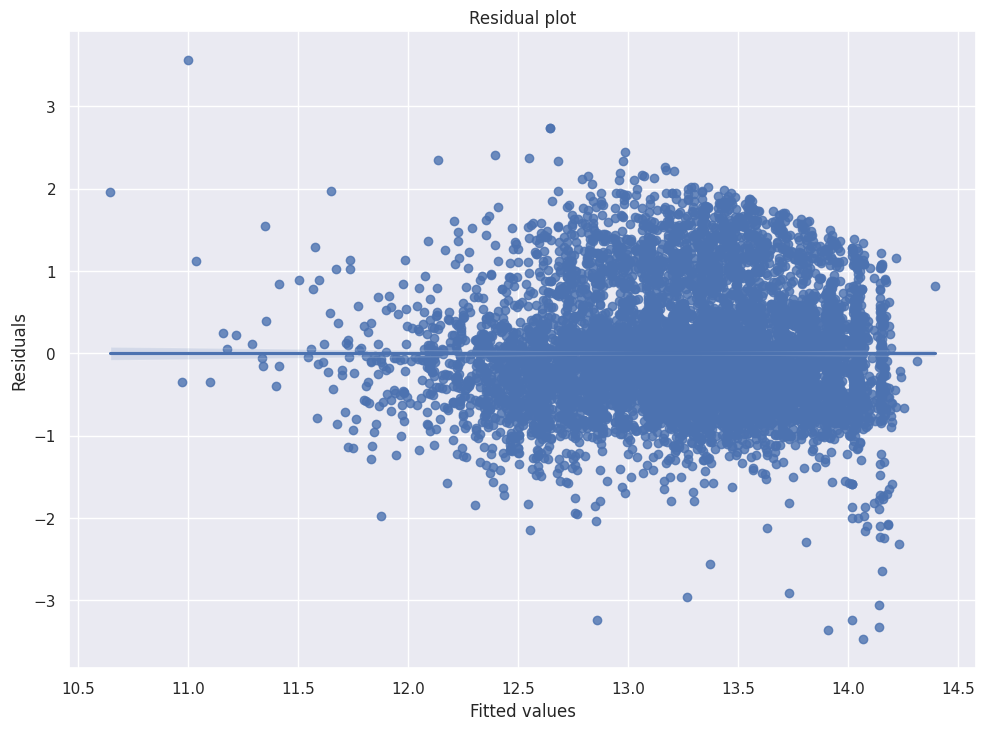

In [45]:
# Residual plot
sns.regplot(x=cars_predictions_lin2_train,y=residuals)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title('Residual plot')

Text(0.5, 1.0, 'Normal Q-Q Plot')

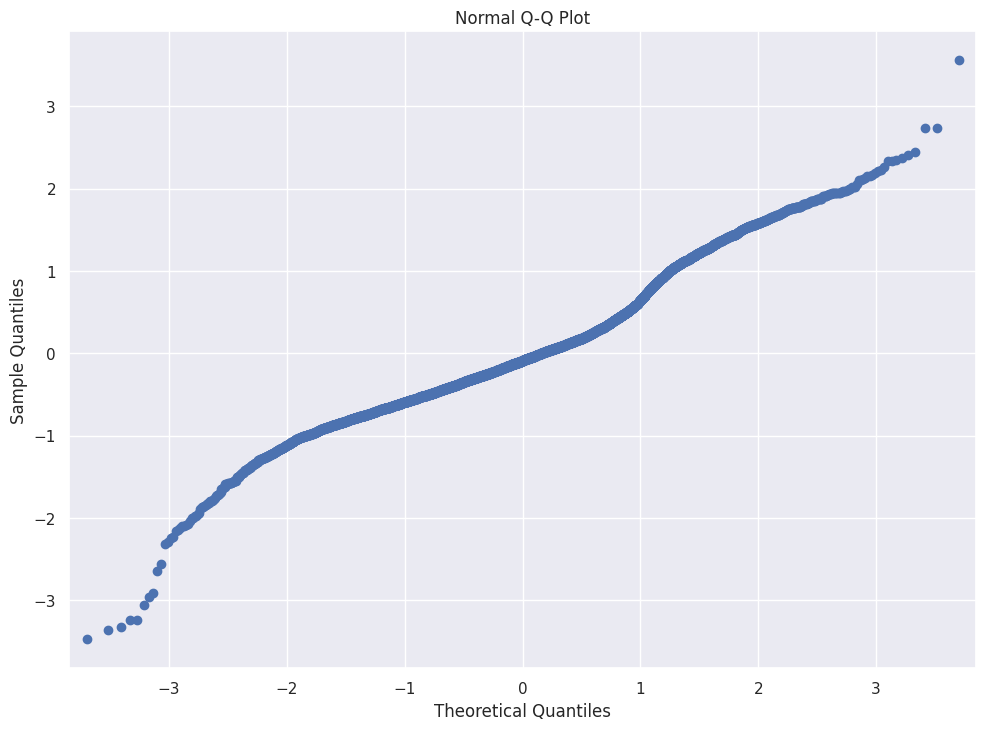

In [46]:
# QQ plot
sm.qqplot(residuals)
plt.title("Normal Q-Q Plot")

In [47]:
"""
Full model with log(price)~kilometer+Age+Brand+Transmission+Owner+FuelType
"""

'\nFull model with log(price)~kilometer+Age+Brand+Transmission+Owner+FuelType\n'

In [48]:
x1 = cars_omit_data.drop(['price','model'], axis='columns', inplace=False)
x1=pd.get_dummies(x1,drop_first=True)
x1=x1.astype(float)
X_train, X_test = train_test_split(x1,test_size=0.3, random_state = 3)

In [49]:
"""
Linear regression for full model
"""

'\nLinear regression for full model\n'

In [50]:
X_train2 = sm.add_constant(X_train)
model_lin3 = sm.OLS(y_train_log, X_train2)
results3=model_lin3.fit()
print(results3.summary())


                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     854.2
Date:                Thu, 13 Aug 2026   Prob (F-statistic):               0.00
Time:                        20:49:01   Log-Likelihood:                -4388.3
No. Observations:                9263   AIC:                             8857.
Df Residuals:                    9223   BIC:                             9142.
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  14.5431    

In [51]:
# Predicting model on test set
X_test=sm.add_constant(X_test)
cars_predictions_lin3_test = results3.predict(X_test)


In [52]:
# Model evaluation on predicted and test
rmse_log(y_test_log,cars_predictions_lin3_test)

{'RMSE-test from model': np.float64(414564.23830847756),
 'Base RMSE': np.float64(815335.427202922)}

In [53]:
# For diagnostics, we need to predict the model on the train data
cars_predictions_lin3_train = results3.predict(X_train2)

In [54]:
"""
Diagnostics
"""

'\nDiagnostics\n'

In [55]:
residuals=y_train_log.iloc[:,0]-cars_predictions_lin3_train

Text(0.5, 1.0, 'Residual plot')

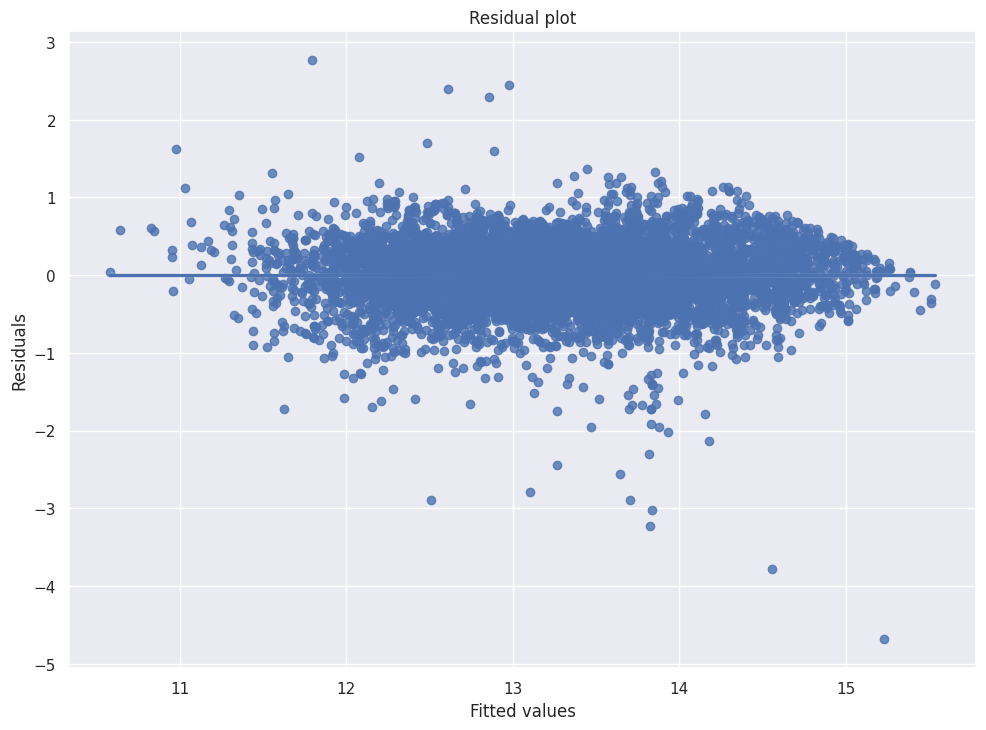

In [56]:
# Residual plot
sns.regplot(x=cars_predictions_lin3_train,y=residuals)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title('Residual plot')

Text(0.5, 1.0, 'Normal Q-Q Plot')

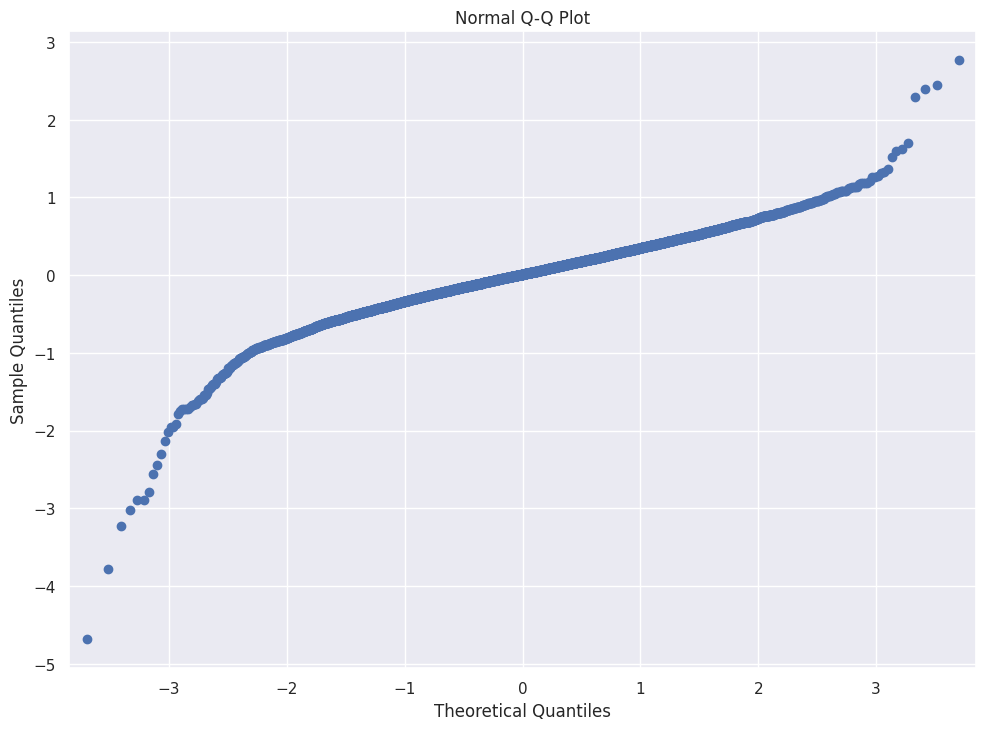

In [57]:
# QQ plot
sm.qqplot(residuals)
plt.title("Normal Q-Q Plot")

In [58]:
# END OF SCRIPT

In [59]:
# Testing the model on a new/sample car


# Example: a 5-year-old Maruti Suzuki, Manual, first owner, Petrol, 40,000 km driven
sample = pd.DataFrame({
    'kilometer': [40000],
    'Age': [5],
    'Brand_Maruti Suzuki': [1],
    'Transmission_Manual': [1],
    'Owner_second': [0],
    'FuelType_Petrol': [1]
})

# Fill in all other dummy columns (that exist in training data) with 0
for col in X_train.columns:
    if col not in sample.columns:
        sample[col] = 0

# Match column order to training data
sample = sample[X_train.columns]

sample = sm.add_constant(sample, has_constant='add')
predicted_log_price = results3.predict(sample)
predicted_price = np.exp(predicted_log_price)

print("Predicted price:", predicted_price.values[0])

Predicted price: 538911.5474768671


In [60]:
new_cars_data = {
    'kilometer': [40000, 20000, 100000, 15000, 60000],
    'Age': [5, 2, 10, 1, 7],
    'Brand': ['Maruti Suzuki', 'Toyota', 'Hyundai', 'BMW', 'Honda'],
    'Transmission': ['Manual', 'Automatic', 'Manual', 'Automatic', 'Manual'],
    'Owner': ['second', 'first', 'second', 'first', 'first'],
    'Fuel': ['Petrol', 'Petrol', 'Diesel', 'Petrol', 'Petrol']
}

sample_cars_df = pd.DataFrame(new_cars_data)

# Rename 'Fuel' to 'FuelType' to match original data
sample_cars_df = sample_cars_df.rename(columns={'Fuel': 'FuelType'})

# Apply one-hot encoding to match the training data (x1)
# The original x1 was created from cars_omit_data.drop(['price','model'], axis='columns', inplace=False)
# followed by pd.get_dummies(x1,drop_first=True)

# Create dummy variables for sample data
sample_cars_df_dummies = pd.get_dummies(sample_cars_df, columns=['Brand', 'Transmission', 'Owner', 'FuelType'], drop_first=True)

# Ensure all columns present in X_train are also present in sample_cars_df_dummies,
# filling missing ones with 0. This is crucial for prediction.
# X_train was derived from x1, so use X_train's columns excluding the 'const' if it's there.

X_train_cols = X_train.columns.tolist()

final_sample_df = pd.DataFrame(columns=X_train_cols)

for i, row in sample_cars_df_dummies.iterrows():
    temp_row_df = pd.DataFrame(row).T
    for col in X_train_cols:
        if col not in temp_row_df.columns:
            temp_row_df[col] = 0
    # Ensure column order matches X_train
    temp_row_df = temp_row_df[X_train_cols]
    final_sample_df = pd.concat([final_sample_df, temp_row_df], ignore_index=True)

# Ensure dtypes are float to match X_train
final_sample_df = final_sample_df.astype(float)

# Add constant for prediction
final_sample_df = sm.add_constant(final_sample_df, has_constant='add')

# Predict log prices
predicted_log_prices = results3.predict(final_sample_df)

# Convert log prices back to actual prices
predicted_prices = np.exp(predicted_log_prices)

print("Predicted prices for the sample cars:")
for i, price in enumerate(predicted_prices):
    print(f"Car {i+1}: ₹{price:,.2f}")


Predicted prices for the sample cars:
Car 1: ₹516,242.18
Car 2: ₹2,170,118.50
Car 3: ₹437,342.17
Car 4: ₹1,289,218.06
Car 5: ₹562,010.77
